In [19]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.cross_decomposition import CCA
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import anndata as ad
import h5py

In [2]:
data_dir = "/Users/mridulav/Downloads/datapreprocessed_output"
base = "mouse_V11L12_038_D1"

X = np.load(os.path.join(data_dir, f"{base}_X_rna.npy"))
Y = np.load(os.path.join(data_dir, f"{base}_X_msi.npy"))

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X)
Y = scaler_y.fit_transform(Y)

print(X.shape, Y.shape)

(2473, 2000) (2473, 2743)


In [3]:
latent_dim = 16

class Encoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class DeepCCA(nn.Module):
    def __init__(self, G, M):
        super().__init__()
        self.gene_encoder = Encoder(G)
        self.msi_encoder = Encoder(M)

    def forward(self, x, y):
        return self.gene_encoder(x), self.msi_encoder(y)

In [4]:
def cca_loss(H1, H2, outdim_size=8):

    r = 1e-4
    eps = 1e-9

    m = H1.size(0)

    H1 = H1 - H1.mean(dim=0)
    H2 = H2 - H2.mean(dim=0)

    S11 = (H1.T @ H1) / (m - 1) + r * torch.eye(H1.size(1), device=H1.device)
    S22 = (H2.T @ H2) / (m - 1) + r * torch.eye(H2.size(1), device=H2.device)
    S12 = (H1.T @ H2) / (m - 1)

    E1, V1 = torch.linalg.eigh(S11)
    E2, V2 = torch.linalg.eigh(S22)

    S11_inv_sqrt = V1 @ torch.diag((E1 + eps).pow(-0.5)) @ V1.T
    S22_inv_sqrt = V2 @ torch.diag((E2 + eps).pow(-0.5)) @ V2.T

    T = S11_inv_sqrt @ S12 @ S22_inv_sqrt

    corr = torch.linalg.svdvals(T)[:outdim_size].sum()

    return -corr

In [5]:
device = torch.device("cpu")

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)

n_val = int(0.1 * len(dataset))
n_train = len(dataset) - n_val

train_set, val_set = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False)

model = DeepCCA(X.shape[1], Y.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val = float("inf")

In [6]:
for epoch in range(200):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        h1, h2 = model(xb, yb)

        loss = cca_loss(h1, h2)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            h1, h2 = model(xb, yb)
            val_loss += cca_loss(h1, h2).item()

    val_loss /= len(val_loader)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/Users/mridulav/best_model3.pt")

    print(epoch, train_loss, val_loss)

0 -2.9987465858459474 -3.711888313293457
1 -4.712993240356445 -4.058730125427246
2 -5.83437557220459 -4.246831893920898
3 -6.531351757049561 -4.366383075714111
4 -7.02888708114624 -4.404001712799072
5 -7.345809459686279 -4.465490341186523
6 -7.531888484954834 -4.486504077911377
7 -7.682329940795898 -4.512582302093506
8 -7.767453002929687 -4.52616548538208
9 -7.8374754905700685 -4.529473304748535
10 -7.881904602050781 -4.530508041381836
11 -7.9153495788574215 -4.524259567260742
12 -7.938866996765137 -4.5268964767456055
13 -7.9536888122558596 -4.535713195800781
14 -7.964425849914551 -4.527640342712402
15 -7.972159481048584 -4.5199809074401855
16 -7.9768294334411625 -4.52774715423584
17 -7.982186603546142 -4.521971225738525
18 -7.98353796005249 -4.522221565246582
19 -7.988045787811279 -4.51836633682251
20 -7.989840030670166 -4.512717247009277
21 -7.99239501953125 -4.512982368469238
22 -7.993287849426269 -4.5193023681640625
23 -7.994496440887451 -4.512758255004883
24 -7.99506950378418 -4.5

In [13]:
model.load_state_dict(torch.load("/Users/mridulav/best_model3.pt"))
model.eval()

H1_all, H2_all = [], []

with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(X_tensor, Y_tensor), batch_size=512):
        h1, h2 = model(xb.to(device), yb.to(device))
        H1_all.append(h1.cpu())
        H2_all.append(h2.cpu())

H1_all = torch.cat(H1_all).numpy()
H2_all = torch.cat(H2_all).numpy()

H1_train = H1_all[train_set.indices]
H2_train = H2_all[train_set.indices]
H1_val   = H1_all[val_set.indices]
H2_val   = H2_all[val_set.indices]

In [14]:
cca = CCA(n_components=8, max_iter=5000)
cca.fit(H1_train, H2_train)

U_val, V_val = cca.transform(H1_val, H2_val)

correlations = [np.corrcoef(U_val[:, i], V_val[:, i])[0, 1] for i in range(8)]
print("Validation canonical correlations:", np.round(correlations, 4))
print("Mean:", np.mean(correlations))

Validation canonical correlations: [0.25   0.6268 0.4007 0.5345 0.4048 0.7573 0.5274 0.3887]
Mean: 0.4862924793493725


In [15]:
dist = cosine_distances(U_val, V_val)
ranks = [np.where(np.argsort(dist[i]) == i)[0][0] for i in range(len(U_val))]
ranks = np.array(ranks)
print("Top-1:", np.mean(ranks == 0))
print("Top-5:", np.mean(ranks < 5))
print("Top-10:", np.mean(ranks < 10))

U_all, V_all = cca.transform(H1_all, H2_all)

Top-1: 0.024291497975708502
Top-5: 0.17408906882591094
Top-10: 0.3117408906882591


In [37]:
with h5py.File("/Users/mridulav/Downloads/datapreprocessed_output/mouse_V11L12_038_D1_preprocessed.h5ad", "r+") as f:
    if "base" in f["uns/log1p"]:
        del f["uns/log1p/base"]
adata = ad.read_h5ad("/Users/mridulav/Downloads/datapreprocessed_output/mouse_V11L12_038_D1_preprocessed.h5ad")
gene_names = adata.var.index.tolist()
msi_names  = adata.uns["msi_features"].tolist()

X_val_np = X[val_set.indices]
Y_val_np = Y[val_set.indices]

gene_mask = X_val_np.std(axis=0) > 0
X_val_np  = X_val_np[:, gene_mask]
gene_names_filtered = [g for g, keep in zip(gene_names, gene_mask) if keep]

msi_mask = Y_val_np.std(axis=0) > 0
Y_val_np = Y_val_np[:, msi_mask]
msi_names_filtered = [m for m, keep in zip(msi_names, msi_mask) if keep]

gene_corrs_all = {}
msi_corrs_all  = {}

for comp in range(8):
    gene_corrs_comp = []
    for i, g in enumerate(gene_names_filtered):
        x = X_val_np[:, i]
        if x.std() == 0:
            continue
        r = pearsonr(x, U_val[:, comp])[0]
        gene_corrs_comp.append({"gene": g, "r": r, "component": comp})

    msi_corrs_comp = []
    for i, m in enumerate(msi_names_filtered):
        y = Y_val_np[:, i]
        if y.std() == 0:
            continue
        r = pearsonr(y, V_val[:, comp])[0]
        msi_corrs_comp.append({"msi": m, "r": r, "component": comp})

    gene_corrs_all[comp] = (
        pd.DataFrame(gene_corrs_comp)
        .assign(r_abs=lambda d: d["r"].abs())
        .sort_values("r_abs", ascending=False)
    )
    msi_corrs_all[comp] = (
        pd.DataFrame(msi_corrs_comp)
        .assign(r_abs=lambda d: d["r"].abs())
        .sort_values("r_abs", ascending=False)
    )


<ipython-input-37-1ff7023fc665>:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-37-1ff7023fc665>:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-37-1ff7023fc665>:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-37-1ff7023fc665>:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-37-1ff7023fc665>:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-37-1ff7023fc665>:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0

In [38]:
barcodes = adata.obs.index.tolist()
df = pd.DataFrame({
    "x": adata.obsm["spatial"][:, 0],
    "y": adata.obsm["spatial"][:, 1],
})
for i in range(8):
    df[f"cca_gene_{i}"] = U_all[:, i]
    df[f"cca_msi_{i}"]  = V_all[:, i]


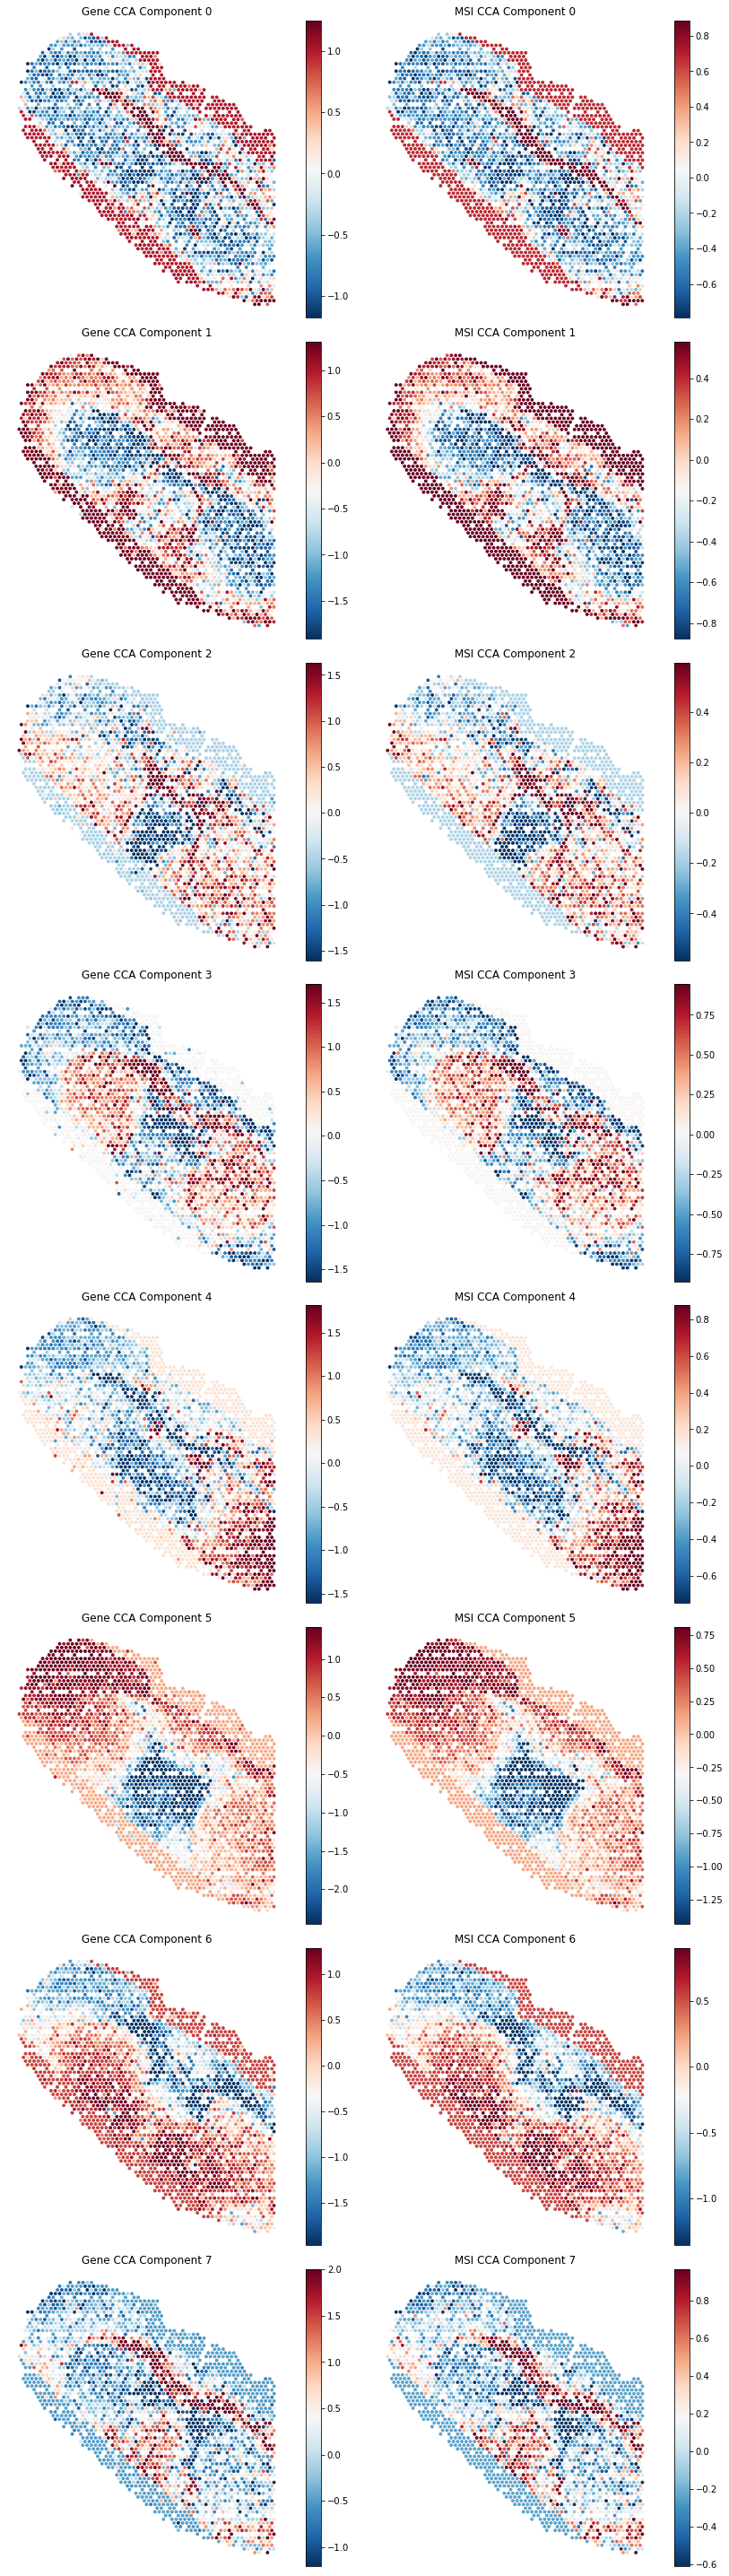

In [39]:
fig, axes = plt.subplots(8, 2, figsize=(12, 40))
for i in range(8):
    for col_idx, (key, label) in enumerate([("cca_gene", "Gene CCA"), ("cca_msi", "MSI CCA")]):
        ax  = axes[i, col_idx]
        col = df[f"{key}_{i}"]
        sc  = ax.scatter(df["x"], df["y"], c=col, cmap="RdBu_r",
                         vmin=np.percentile(col, 5), vmax=np.percentile(col, 95), s=8)
        plt.colorbar(sc, ax=ax)
        ax.set_title(f"{label} Component {i}")
        ax.set_aspect("equal")
        ax.axis("off")

plt.tight_layout()
plt.savefig("/Users/mridulav/spatial_cca_components.png", dpi=150)
plt.show()

In [40]:
best_comp = 6

sig_genes = gene_corrs_all[best_comp][gene_corrs_all[best_comp]["r_abs"] > 0.25]["gene"].tolist()
sig_msi   = msi_corrs_all[best_comp][msi_corrs_all[best_comp]["r_abs"] > 0.5]["msi"].tolist()

print("Sig genes:", len(sig_genes))
print("Sig msi:", len(sig_msi))

pairs = pd.DataFrame([
    {"gene": g, "msi": m, "component": best_comp,
     "r": pearsonr(X[:, gene_names.index(g)], Y[:, msi_names.index(m)])[0]}
    for g in sig_genes for m in sig_msi
]).assign(r_abs=lambda d: d["r"].abs()).sort_values("r_abs", ascending=False)

print(pairs.head(20)[["gene", "msi", "r"]].to_string(index=False))
pairs.to_csv("/Users/mridulav/gene_metabolite_pairs_mouse_V11L12_038_D1.csv", index=False)

Sig genes: 208
Sig msi: 48
  gene                   msi         r
   Dbi          mz.284.77471  0.290206
   Dbi         mz.569.518775  0.286126
   Dbi mz.286.77187000000004  0.286022
   Dbi          mz.282.77783  0.283467
   Dbi         mz.573.512445  0.281339
   Dbi mz.150.88660499999997  0.280346
   Dbi         mz.288.768965  0.280277
   Dbi         mz.152.883785  0.279403
   Dbi         mz.565.525445  0.278708
   Dbi         mz.301.764925  0.277580
   Dbi         mz.150.886795  0.277119
   Dbi          mz.305.75867  0.273780
   Dbi mz.154.88083999999998  0.267942
  Wfs1         mz.171.006475 -0.261896
   Dbi          mz.342.73335  0.252990
Pnmal2         mz.171.006475 -0.248567
  Wfs1          mz.342.00199 -0.247697
   Dbi mz.210.84250500000002  0.243222
   Dbi          mz.344.73039  0.240794
 Thbs4 mz.286.77187000000004  0.238859
